### 1. Preparación del Modelo y Prevención de Data Leakage (Fuga de Datos)
Seleccionamos nuestros biomarcadores y variables físicas, excluyendo intencionalmente la presión arterial directa y los identificadores. Llenaremos cualquier valor nulo restante en variables bioquímicas con la mediana para estabilizar el modelo.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import os

# Creación de carpeta para modelos exportados
os.makedirs("../models", exist_ok=True)

# Definición de ruta para el motor
model_path = "../models/motor_hipertension_rf.pkl"

# Carga de datos de la sala de procesamiento
input_path = "../data/processed/Hipertension_Features.csv"
df = pd.read_csv(input_path)

# Se seleccionará un escuadrón de características clínicas y físicas

features = [
    'edad', 'sueno_horas', 'actividad_total', 'imc_calculado',
    'indice_cintura_talla', 'indice_tyg', 'valor_colesterol_ldl',
    'valor_insulina', 'valor_proteinac_reactiva'
]

# Creación de sub-dataframe
df_model = df[features + ['riesgo_hipertension']].copy()

# Se busca cualquier infinito positivo o negativo y se convierte a un valor nulo (NaN)
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# Imputación rápida de seguridad: si algún examen de sangre faltó, se usará la mediana
df_model = df_model.fillna(df_model.median())

# X = Las pistas (Features), y = El resultado a adivinar (Target)
X = df_model[features]
y = df_model['riesgo_hipertension']

# Se separa el 80% de los datos para que el modelo lo estudie y el 20% para hacerle tests
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos listos. El modelo entrenará con {len(X_train)} pacientes y se evaluará con {len(X_test)}.")

Datos listos. El modelo entrenará con 3490 pacientes y se evaluará con 873.


### 2. Entrenamiento del Random Forest
Se instancia el modelo con 100 árboles de decisión y lo ajustamos a nuestros datos de entrenamiento. Luego, evaluamos su precisión con los datos de prueba.

In [5]:
# Creación de motor predictivo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# Hacer el test
predicciones = modelo_rf.predict(X_test)

# Calificar el examen
print("Reporte de Precisión del Motor Predictivo:\n")
print(classification_report(y_test, predicciones))

Reporte de Precisión del Motor Predictivo:

              precision    recall  f1-score   support

           0       0.94      0.83      0.88       309
           1       0.91      0.97      0.94       564

    accuracy                           0.92       873
   macro avg       0.93      0.90      0.91       873
weighted avg       0.92      0.92      0.92       873



### 3. Extracción de Lógica Clínica (Feature Importance)
¿Qué variables tienen mayor peso matemático al detonar una alerta de hipertensión?

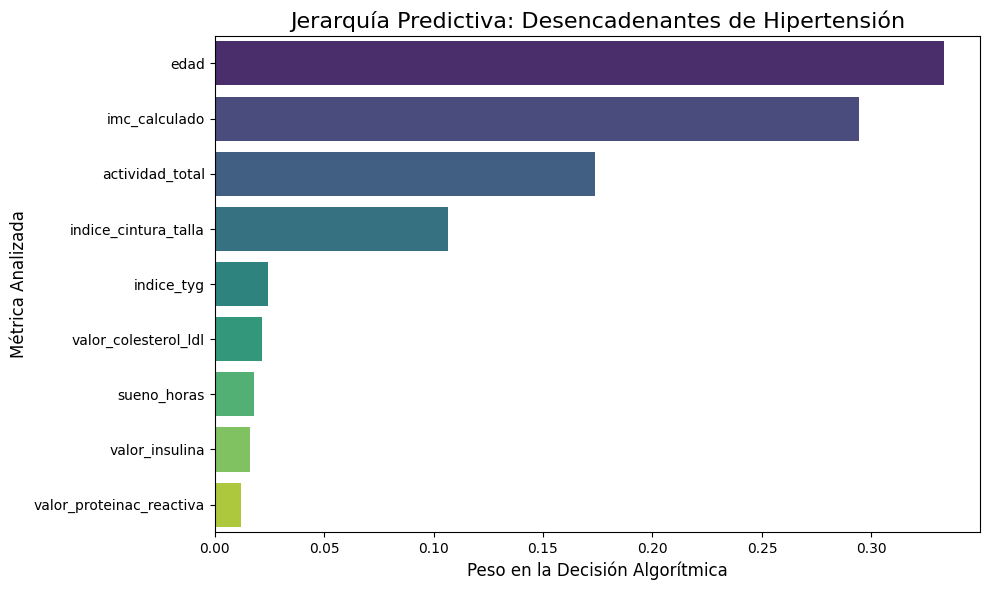

Éxito. El motor predictivo ha sido empaquetado y guardado en: ../models/motor_hipertension_rf.pkl


In [6]:
# Extracción de peso
importancias = modelo_rf.feature_importances_

# Creación de DataFrame ordenado
df_importancia = pd.DataFrame({
    'Biomarcador': features,
    'Impacto_Predictivo': importancias
}).sort_values(by='Impacto_Predictivo', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, 
            x='Impacto_Predictivo', 
            y='Biomarcador',
            hue='Biomarcador', 
            palette='viridis',
            legend=False)
plt.title('Jerarquía Predictiva: Desencadenantes de Hipertensión', fontsize=16)
plt.xlabel('Peso en la Decisión Algorítmica', fontsize=12)
plt.ylabel('Métrica Analizada', fontsize=12)
plt.tight_layout()
plt.show()

# Exportación del modelo Random Forest
joblib.dump(modelo_rf, model_path)

print(f"Éxito. El motor predictivo ha sido empaquetado y guardado en: {model_path}")
